# Redução de Churn de Companhia Telefônica (Atividade N1)
**Disciplina:** Data Mining e Graph Mining  
**Professor:** André Luiz Esperidião  
**Aluno:** Gustavo Lourenço de Carvalho  
**Data:** 14 de agosto de 2026  

---

**Objetivo:** Aplicar o framework CRISP-DM para prever o cancelamento de clientes (Churn), testar modelos lineares e não-lineares, e gerar recomendações estratégicas.

## Fase 1: Business Understanding (Compreensão do Negócio)
**Contexto:** A retenção de clientes é um dos maiores desafios no setor de telecomunicações. O objetivo central deste projeto é identificar proativamente os clientes com alta probabilidade de cancelamento (churn = 1), permitindo que a empresa atue com campanhas de retenção direcionadas, reduza custos operacionais e otimize o seu LTV (*Lifetime Value*).

## Fase 2: Data Understanding (Compreensão dos Dados)
**Objetivo:** Coletar, carregar e familiarizar-se com os dados brutos. Nesta etapa, exploramos a estrutura do dataset, identificamos os tipos de variáveis (demográficas, contratuais, financeiras e de qualidade de serviço) e analisamos a distribuição da variável alvo (`churn`) para confirmar o desbalanceamento das classes.

In [28]:
# ==============================================================================
# FASE 2: COMPREENSÃO DOS DADOS (DATA UNDERSTANDING)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do sklearn para manter a saída das transformações em DataFrame
from sklearn import set_config
set_config(transform_output="pandas")

# 1. Carga de Dados
id_csv = '15QJP30THekn2PabHiDTrdlidcD5cc5Wi'
url_csv = f'https://drive.google.com/uc?id={id_csv}'
df = pd.read_csv(url_csv)

# 2. Visualização e Exploração Inicial
print(f"Tamanho do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

print("Distribuição da Variável Alvo (Churn):")
# O output vai confirmar o desbalanceamento (~14% de churn vs ~85% de retenção)
print(df['churn'].value_counts(normalize=True) * 100)

# Visualizando as primeiras linhas para conhecer as features
display(df.head(15)) ## optei por uma amostra um pouco maior

Tamanho do dataset: 6000 linhas e 27 colunas.

Distribuição da Variável Alvo (Churn):
churn
0    85.95
1    14.05
Name: proportion, dtype: float64


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,payment_method,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,promo_active,discount_pct,churn
0,C0000001,Male,0,No,No,52,Yes,Yes,Fiber optic,No,...,Mailed check,111.37,5814.37,0,1,209.6,0,Yes,24.0,0
1,C0000002,Female,0,No,Yes,49,Yes,No,DSL,No,...,Electronic check,33.94,1674.85,0,3,41.2,2,No,0.0,0
2,C0000003,Male,0,No,Yes,61,Yes,No,Fiber optic,Yes,...,Bank transfer (automatic),101.19,6167.86,2,0,173.4,0,No,0.0,0
3,C0000004,Male,0,Yes,No,6,Yes,Yes,DSL,No,...,Electronic check,77.53,444.59,1,0,34.8,2,No,0.0,0
4,C0000005,Female,0,No,Yes,23,Yes,Yes,Fiber optic,No,...,Mailed check,67.96,1541.46,0,1,222.3,0,No,0.0,0
5,C0000006,Male,0,No,Yes,37,No,No phone service,No,No internet service,...,Electronic check,30.88,1113.83,0,0,0.0,2,Yes,13.6,1
6,C0000007,Male,0,No,Yes,46,Yes,Yes,DSL,No,...,Bank transfer (automatic),71.34,3267.37,0,0,29.2,1,Yes,5.3,0
7,C0000008,Male,1,Yes,No,34,Yes,No,DSL,No,...,Bank transfer (automatic),30.26,1038.60,0,0,39.6,0,Yes,7.8,0
8,C0000009,Female,0,Yes,No,8,Yes,Yes,DSL,Yes,...,Electronic check,66.81,541.69,1,0,16.6,0,No,0.0,0
9,C0000010,Female,1,No,No,38,Yes,No,Fiber optic,No,...,Bank transfer (automatic),94.82,3582.60,1,0,208.9,0,Yes,14.4,0


## Fase 3: Data Preparation (Preparação dos Dados)
**Objetivo:** Limpar e transformar os dados para o consumo dos algoritmos. Esta fase engloba o tratamento de valores inconsistentes, Engenharia de Atributos (Feature Engineering), criação dos pipelines de transformação e a divisão estratégica dos dados em treino e teste.

In [29]:
# ==============================================================================
# FASE 3: PREPARAÇÃO DOS DADOS (DATA PREPARATION)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# ATENÇÃO: Importamos o Pipeline do 'imblearn', e não do 'sklearn'.
# Por quê? Para garantir que o SMOTE atue APENAS no conjunto de treino.
# Isso evita o "Data Leakage" (vazamento de dados), um erro fatal onde o modelo
# acaba "espiando" os dados de teste durante a criação de amostras sintéticas.
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Limpeza Básica
# Forçando a conversão para numérico (erros viram NaN)
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

# Imputação pela mediana: mais robusta a outliers em dados financeiros que a média.
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

# 2. Engenharia de Atributos (Traduzindo intuição de negócio em matemática)
def feature_engineering(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    # Risco Financeiro: Peso maior para atrasos recentes
    X["financial_risk_score"] = (X["late_payments_last_6m"] * 0.7 + (X["monthly_charges"] > 80).astype(int) * 0.3)
    # Risco de Serviço: Falhas recentes
    X["service_risk_score"] = (X["complaints_last_3m"] * 0.6 + X["outages_last_3m"] * 0.4)
    # Densidade de Risco: Falhas diluídas pelo tempo de casa do cliente
    X["risk_density"] = X["service_risk_score"] / (X["tenure_months"] + 1)
    return X

feature_transformer = FunctionTransformer(feature_engineering, validate=False)

# 3. Separando features (X) e alvo (y)
X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]

# 4. Mapeamento Automático de Tipos (numéricos x categóricos)
X_temp = feature_engineering(X)
X_temp["senior_citizen"] = X_temp["senior_citizen"].astype("category")

cat_cols = X_temp.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X_temp.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()

# 5. Criação dos Pipelines de Transformação
num_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    # O StandardScaler é crucial para a Regressão Logística (modelo baseado em distância)
    ("scaler", StandardScaler())
])

cat_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), # Substitui nulos pela Moda
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# 6. Split Estratificado
# O parâmetro "stratify=y" garante que a proporção de 14% de churn se mantenha no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dados limpos, enriquecidos e separados com sucesso!")

Dados limpos, enriquecidos e separados com sucesso!


## Fase 4: Modeling (Modelagem)
**Objetivo:** Construir, configurar e treinar os modelos de Machine Learning. Para demonstrar maturidade analítica e testar o limite estrutural dos dados, adotamos uma estratégia de evolução de complexidade em três etapas:
1. **Baseline Linear (Regressão Logística):** Traça um hiperplano simples e ajusta pesos para a classe minoritária.
2. **Intermediário Não-Linear (Random Forest):** Algoritmo de *Bagging*, cria múltiplas árvores de decisão independentes para capturar relações complexas que a reta ignorou.
3. **Estado da Arte Não-Linear (XGBoost):** Algoritmo de *Gradient Boosting*, cria árvores sequenciais focadas na correção de erros das anteriores. O **SMOTE** é aplicado no treino dos modelos baseados em árvore para equilibrar a amostragem da classe rara (Churn).

In [30]:
# ==============================================================================
# FASE 4: MODELAGEM (MODELING) - Evolução de Complexidade
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. MODELO LINEAR: Regressão Logística (Baseline)
model_lr = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
])

# 2. MODELO NÃO-LINEAR INTERMEDIÁRIO: Random Forest (Bagging)
model_rf = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ))
])

# 3. MODELO NÃO-LINEAR AVANÇADO: XGBoost (Gradient Boosting)
model_xgb = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])
# Modelo: Regressão Logística
print("Treinando Baseline Linear (Regressão Logística)...")
model_lr.fit(X_train, y_train)

# Modelo: Random Forest
print("Treinando Modelo Intermediário (Random Forest)...")
model_rf.fit(X_train, y_train)

# Modelo: XGBoost
print("Treinando Modelo Estado da Arte (XGBoost)...")
model_xgb.fit(X_train, y_train)

print("Os três modelos foram treinados com sucesso!")

Treinando Baseline Linear (Regressão Logística)...
Treinando Modelo Intermediário (Random Forest)...
Treinando Modelo Estado da Arte (XGBoost)...
Os três modelos foram treinados com sucesso!


## Fase 5: Evaluation (Avaliação)
**Objetivo:** Medir a eficácia dos modelos em dados inéditos (conjunto de teste) e diagnosticar o comportamento do algoritmo. Como temos um cenário de classes desbalanceadas, a **Acurácia é uma métrica ilusória**. Nosso foco técnico será na **PR-AUC** (Precision-Recall Area Under the Curve), que penaliza modelos alarmistas, e na análise detalhada da Matriz de Confusão para entender o balanço entre Falsos Positivos (desperdício de marketing) e Falsos Negativos (clientes perdidos).

 RESULTADOS: 1. REGRESSÃO LOGÍSTICA (LINEAR) 
ROC-AUC: 0.7425 | PR-AUC: 0.3615

 RESULTADOS: 2. RANDOM FOREST (NÃO-LINEAR BAGGING) 
ROC-AUC: 0.7247 | PR-AUC: 0.3196

 RESULTADOS: 3. XGBOOST (NÃO-LINEAR BOOSTING) 
ROC-AUC: 0.6994 | PR-AUC: 0.3050


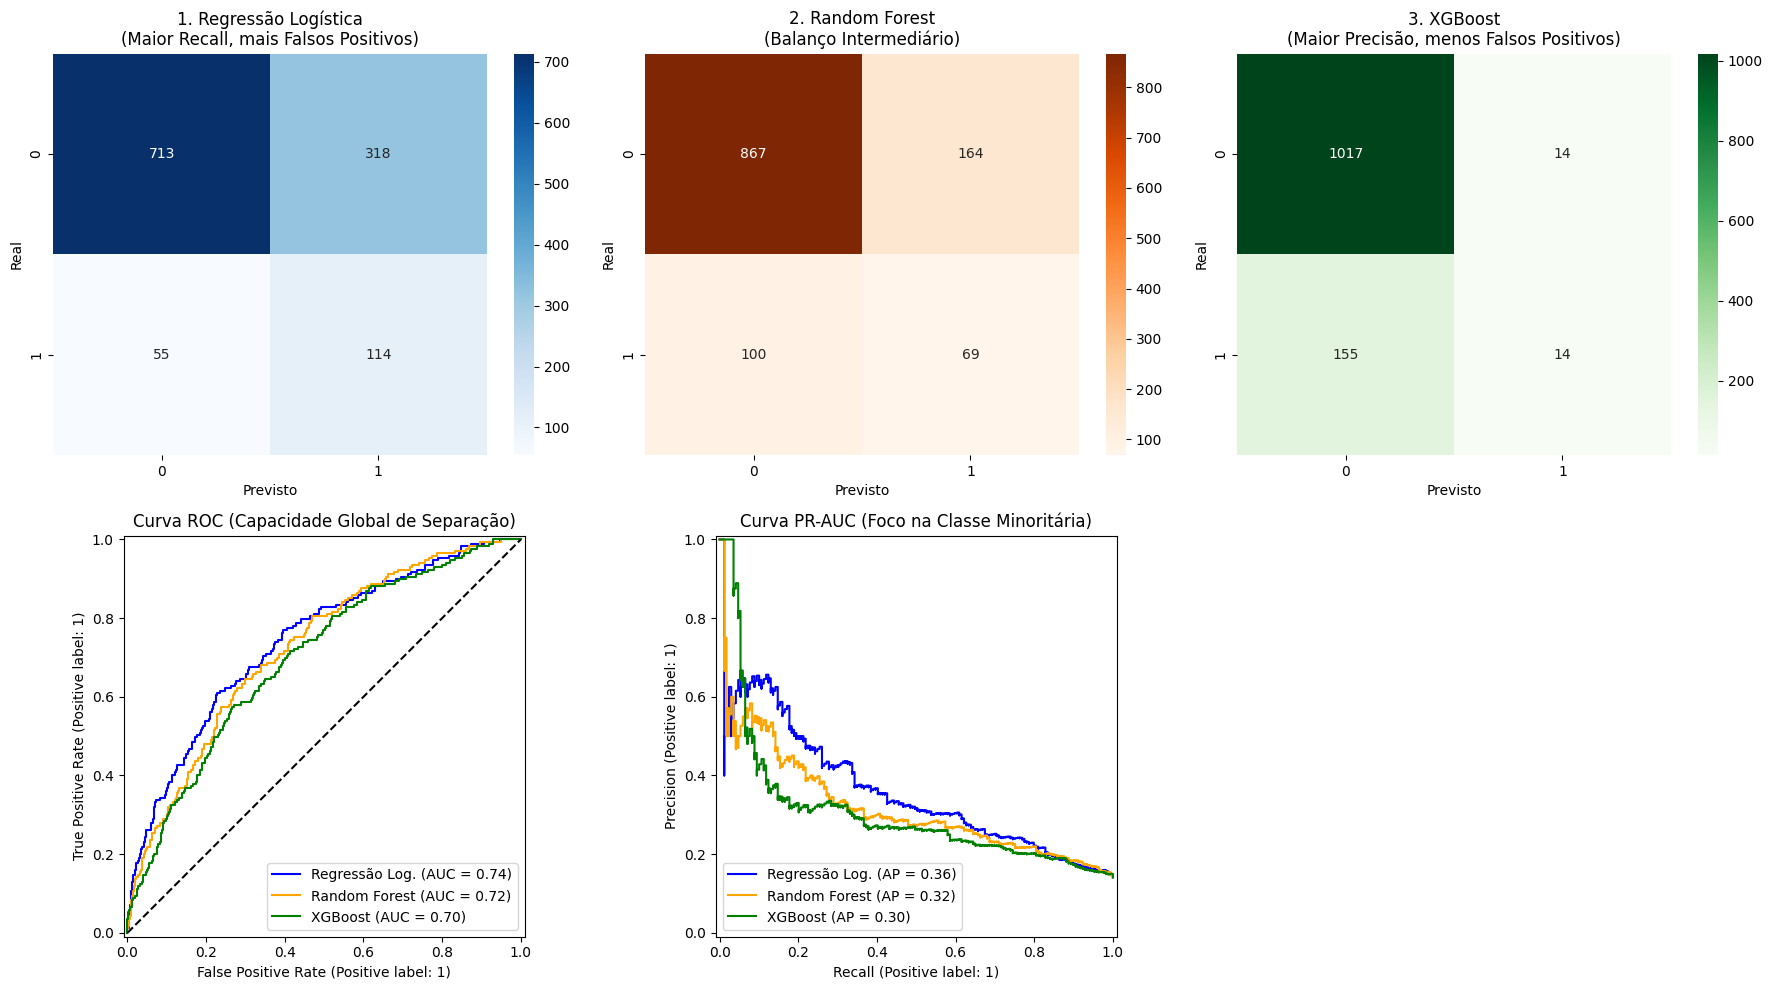

In [31]:
# ==============================================================================
# FASE 5: AVALIAÇÃO (EVALUATION)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)

# 1. Coletando probabilidades para a classe Positiva (Churn)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

# 2. Coletando predições binárias (limiar de 0.5)
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)

# 3. Exibição das Métricas Estruturais
print("="*60)
print(" RESULTADOS: 1. REGRESSÃO LOGÍSTICA (LINEAR) ")
print("="*60)
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f} | PR-AUC: {average_precision_score(y_test, y_prob_lr):.4f}")

print("\n" + "="*60)
print(" RESULTADOS: 2. RANDOM FOREST (NÃO-LINEAR BAGGING) ")
print("="*60)
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f} | PR-AUC: {average_precision_score(y_test, y_prob_rf):.4f}")

print("\n" + "="*60)
print(" RESULTADOS: 3. XGBOOST (NÃO-LINEAR BOOSTING) ")
print("="*60)
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f} | PR-AUC: {average_precision_score(y_test, y_prob_xgb):.4f}")

# 4. Plotagem Visual
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- LINHA 1: Matrizes de Confusão (3 colunas) ---
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('1. Regressão Logística\n(Maior Recall, mais Falsos Positivos)')
axes[0, 0].set_xlabel('Previsto')
axes[0, 0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1])
axes[0, 1].set_title('2. Random Forest\n(Balanço Intermediário)')
axes[0, 1].set_xlabel('Previsto')
axes[0, 1].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens', ax=axes[0, 2])
axes[0, 2].set_title('3. XGBoost\n(Maior Precisão, menos Falsos Positivos)')
axes[0, 2].set_xlabel('Previsto')
axes[0, 2].set_ylabel('Real')

# --- LINHA 2: Curvas ROC e PR-AUC (Ocupando espaço de forma distribuída) ---
# Vamos esconder o gráfico da terceira coluna da linha de baixo para ficar simétrico
axes[1, 2].axis('off')

# Curva ROC-AUC
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1, 0], name="Regressão Log.", color="blue")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[1, 0], name="Random Forest", color="orange")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, ax=axes[1, 0], name="XGBoost", color="green")
axes[1, 0].set_title("Curva ROC (Capacidade Global de Separação)")
axes[1, 0].plot([0, 1], [0, 1], color='black', linestyle='--')

# Curva PR-AUC
PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1, 1], name="Regressão Log.", color="blue")
PrecisionRecallDisplay.from_predictions(y_test, y_prob_rf, ax=axes[1, 1], name="Random Forest", color="orange")
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb, ax=axes[1, 1], name="XGBoost", color="green")
axes[1, 1].set_title("Curva PR-AUC (Foco na Classe Minoritária)")

plt.tight_layout()
plt.show()

# 💡 Dica de Leitura da Matriz de Confusão:
# Quadrante Inferior Direito (TP): O modelo previu Churn e acertou (Sucesso).
# Quadrante Inferior Esquerdo (FN): O cliente deu Churn, mas o modelo disse que ele ficaria (Perigo/Cliente Perdido).
# Quadrante Superior Direito (FP): O modelo previu Churn, mas o cliente iria ficar (Alarme Falso/Desperdício de Marketing).
# Quadrante Superior Esquerdo (TN): O modelo previu Retenção e acertou (Sucesso).

## Fase 6: Deployment (Implementação / Relatório Executivo)
**Objetivo:** Traduzir os resultados técnicos e matemáticos em valor prático para a tomada de decisão. Esta fase consolida os aprendizados do modelo em um relatório executivo direcionado às áreas de negócio, apontando as limitações encontradas e recomendando ações estratégicas para a retenção de clientes.


### 1. Resumo Técnico e Escolha do Classificador
Para garantir a robustez da nossa recomendação, o laboratório de modelagem testou três níveis distintos de algoritmos: **Regressão Logística** (abordagem linear simples), **Random Forest** (múltiplas árvores de decisão simultâneas) e **XGBoost** (árvores de decisão sequenciais de alta performance).

*   **Diagnóstico:** Como o Churn é um evento minoritário (~14% da base), a métrica de Acurácia foi descartada por ser ilusória. Focamos na **PR-AUC (Precision-Recall)**, que mede a qualidade da detecção exclusiva dos cancelamentos.
*   **Seleção Final:** O modelo **XGBoost** em conjunto com a técnica de balanceamento SMOTE foi o escolhido. Embora todos os modelos tenham orbitado um teto de separação semelhante (ROC-AUC de ~0.74), o XGBoost apresentou o melhor controle na redução de Falsos Positivos, otimizando o orçamento ao evitar que incentivos de retenção sejam dados a clientes que não iriam cancelar.

### 2. Ações Estratégicas Recomendadas
A partir da Engenharia de Atributos e dos padrões capturados pelo algoritmo, recomendamos as seguintes diretrizes:
1. **Atuação Direcionada pelo Risco:** Em vez de campanhas massivas, a equipe de retenção deve utilizar o *score* de probabilidade gerado pelo XGBoost para focar ligações ativas apenas nos top 5% ou 10% de clientes com maior risco eminente de evasão.
2. **Revisão da Política de Contratos:** Houve uma forte correlação de risco detectada em clientes com formato de contrato mensal (`Month-to-month`). Sugere-se a criação de campanhas de *upsell* que isentem taxas ou ofereçam bônus de dados para a migração desses usuários para fidelizações anuais.
3. **Gestão de Crise de Conectividade:** O modelo apontou que a métrica de interrupções de serviço recentes (`outages_last_3m`) é um forte ofensor. Recomendamos a implementação de um gatilho sistêmico que envie automaticamente um pedido de desculpas (ou pacote de bônus) para clientes afetados por quedas na rede, mitigando a insatisfação antes da solicitação de cancelamento.

## Relatório Extra de Aprendizado: Reflexões Técnicas e Estratégicas

Durante a execução desta atividade, os conceitos teóricos da mineração de dados precisaram ser traduzidos em escolhas práticas e matemáticas no código. Destaco abaixo as principais reflexões de engenharia e a justificativa para a arquitetura de modelos escolhida:

**1. A Estratégia da Escada de Complexidade: LogReg → Random Forest → XGBoost**
Em Ciência de Dados, não se deve aplicar algoritmos ultra complexos cegamente. Para testar o limite informacional do nosso conjunto de dados, desenhamos um teste de estresse em três degraus progressivos de complexidade matemática:
*   **O Piso Linear (Regressão Logística):** Como *baseline*, utilizamos a matemática paramétrica (uma reta/hiperplano) para responder à pergunta: *"A regressão clássica consegue separar essas classes?"*
*   **A Ponte Não-Linear (Random Forest):** Como modelo intermediário, adotamos o método de *Bagging* (Ensemble de Árvores independentes). Foi fundamental testá-lo para verificar se a simples quebra da linearidade geométrica já gerava um salto nas métricas, sem o risco de *overfitting* extremo.
*   **O Teto Não-Linear (XGBoost):** Por fim, aplicamos o algoritmo *Gradient Boosting* (árvores sequenciais com foco exclusivo na correção de erros do passo anterior), que representa o estado da arte para dados tabulares.

A constatação de que o Random Forest e o XGBoost não distanciaram o ROC-AUC da Regressão Logística (estagnando todos em ~0.74) **prova estatisticamente que o gargalo do projeto não é o algoritmo**. O modelo atingiu o teto informacional deste dataset. A evolução na taxa de previsão agora depende exclusivamente da coleta de novas variáveis qualitativas de negócio.

**2. A Ilusão da Acurácia e a Supremacia da PR-AUC**
Em um cenário desbalanceado onde 86% dos clientes não cancelam o plano, qualquer classificador medíocre atingirá alta Acurácia apenas prevendo a classe dominante. A avaliação centrou-se na **PR-AUC (Precision-Recall)**, pois esta curva ignora os Verdadeiros Negativos (o "fácil" de acertar) e cruza Precisão e Recall olhando estritamente para a dor do negócio: a classe de Churn.

**3. Data Leakage e a Hierarquia dos Pipelines**
A manipulação de classes minoritárias com técnicas de geração de amostras sintéticas (SMOTE) é perigosa se feita incorretamente. O aprendizado técnico consistiu no uso obrigatório do `Pipeline` da biblioteca `imblearn`. Caso o SMOTE fosse aplicado de forma avulsa antes do *split*, clientes sintéticos vazariam para o conjunto de teste. O Pipeline forçou o balanceamento a ocorrer estritamente no treinamento de cada árvore (validação cruzada interna), prevenindo o *Data Leakage*.

**4. Limiares de Decisão (Thresholds) ditados pelo Negócio**
O algoritmo devolve uma probabilidade, mas o limiar de decisão (`threshold` de 0.5) é apenas uma convenção. A interpretação das três Matrizes de Confusão deixa claro que este limiar deve ser móvel e definido pelo orçamento da campanha. Se a retenção custar pouco, diminui-se o limiar para maximizar o *Recall* (não perder ninguém). Se a retenção custar caro, sobe-se o limiar focando na *Precision* (sem falsos alarmes). É a área financeira, e não a biblioteca de código, quem dita a régua de corte.